# Neural external-field pseudo-likelihood for DGL Fraud Yelp

We fit the three-relation Ising-type model

$$
\mathbb P_{\beta,\theta}(\sigma\mid X,G)
\propto
\exp\left\{
\sum_{r=1}^3 \beta_r \sum_{(i,j)\in E_r}\sigma_i\sigma_j
+
2\sum_{i=1}^n \sigma_i b_\theta(X_i)
\right\},
\qquad \sigma_i\in\{-1,1\}.
$$

Here \(b_\theta:\mathbb R^d\to\mathbb R\) is a neural network. This replaces the linear external field \(X_i^\top\gamma\) by a nonlinear learned field \(b_\theta(X_i)\).

The full likelihood is not used, since the partition function is intractable. Instead, we fit the pseudo-likelihood. Define

$$
S_{ir}=\sum_{j:(j,i)\in E_r}\sigma_j,
\qquad r=1,2,3.
$$

Then

$$
h_i
=
\sum_{r=1}^3 \beta_r S_{ir}
+
2b_\theta(X_i),
$$

and

$$
\mathbb P_{\beta,\theta}(\sigma_i=1\mid \sigma_{-i},X,G)
=
\operatorname{logit}^{-1}(2h_i).
$$

Thus fitting the pseudo-likelihood is just binary cross-entropy training with logits \(2h_i\).


In [1]:
# If needed, install dependencies first. Pick the DGL wheel matching your PyTorch version.
# %pip install -q scikit-learn pandas matplotlib
# %pip install -q dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html


In [2]:
import math
import random
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt

import dgl
from dgl.data import FraudYelpDataset


SEED = 717

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

## Load the dataset

DGL's Fraud Yelp dataset has three edge relations. We use

$$
(\beta_1,\beta_2,\beta_3)
=
(\beta_{\text{net\_rur}},\beta_{\text{net\_rsr}},\beta_{\text{net\_rtr}}).
$$

The binary labels are converted by

$$
\sigma_i=2y_i-1.
$$


In [3]:
dataset = FraudYelpDataset(
    random_seed=SEED,
    train_size=0.7,
    val_size=0.1,
    verbose=True,
)

g = dataset[0]

print(g)
print("node types:", g.ntypes)
print("edge types:", g.etypes)
print("canonical edge types:", g.canonical_etypes)


Done loading data from cached files.
Graph(num_nodes={'review': 45954},
      num_edges={('review', 'net_rsr', 'review'): 6805486, ('review', 'net_rtr', 'review'): 1147232, ('review', 'net_rur', 'review'): 98630},
      metagraph=[('review', 'review', 'net_rsr'), ('review', 'review', 'net_rtr'), ('review', 'review', 'net_rur')])
node types: ['review']
edge types: ['net_rsr', 'net_rtr', 'net_rur']
canonical edge types: [('review', 'net_rsr', 'review'), ('review', 'net_rtr', 'review'), ('review', 'net_rur', 'review')]


In [4]:
def get_node_data(g, key, ntype=None):
    if ntype is None:
        if len(g.ntypes) != 1:
            raise ValueError("Pass ntype explicitly when the graph has multiple node types.")
        ntype = g.ntypes[0]

    value = g.ndata[key]
    if isinstance(value, dict):
        return value[ntype]
    return value


ntype = g.ntypes[0]

X_raw = get_node_data(g, "feature", ntype).float()
y01 = get_node_data(g, "label", ntype).long()

train_mask = get_node_data(g, "train_mask", ntype).bool()
val_mask = get_node_data(g, "val_mask", ntype).bool()
test_mask = get_node_data(g, "test_mask", ntype).bool()

sigma_all = 2.0 * y01.float() - 1.0

summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "n": [
        int(train_mask.sum()),
        int(val_mask.sum()),
        int(test_mask.sum()),
        int(y01.numel()),
    ],
    "positives_label_1": [
        int(y01[train_mask].sum()),
        int(y01[val_mask].sum()),
        int(y01[test_mask].sum()),
        int(y01.sum()),
    ],
})

summary["positive_rate"] = summary["positives_label_1"] / summary["n"]
summary


,split,n,positives_label_1,positive_rate
0,train,32167,4726,0.146921
1,validation,4595,651,0.141676
2,test,9192,1300,0.141427
3,all,45954,6677,0.145297


In [5]:
EDGE_TYPES = ["net_rur", "net_rsr", "net_rtr"]

BETA_LABELS = [
    "beta_1: net_rur",
    "beta_2: net_rsr",
    "beta_3: net_rtr",
]

missing = [e for e in EDGE_TYPES if e not in g.etypes]
if missing:
    raise ValueError(f"Missing expected edge types: {missing}. Present edge types: {g.etypes}")

for etype in EDGE_TYPES:
    print(f"{etype:8s}: {g.num_edges(etype=etype):,} directed edges")


net_rur : 98,630 directed edges
net_rsr : 6,805,486 directed edges
net_rtr : 1,147,232 directed edges


## Standardize node features

The neural network receives standardized features. The mean and standard deviation are computed from the training nodes only.

Unlike the previous linear notebook, we do not add an intercept column to \(X\). The neural net has its own bias terms.


In [6]:
def standardize_with_train_stats(X, train_mask, eps=1e-12):
    X = X.float()
    mean = X[train_mask].mean(dim=0)
    std = X[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
    X_std = (X - mean) / std
    return X_std, mean, std


X, X_mean, X_std = standardize_with_train_stats(X_raw, train_mask)

print("raw feature shape:", tuple(X_raw.shape))
print("standardized feature shape:", tuple(X.shape))


raw feature shape: (45954, 32)
standardized feature shape: (45954, 32)


## Construct the local relation fields \(S_{ir}\)

For fair train/validation/test evaluation, we use only training labels when forming neighbor sums. That means

$$
\sigma_j^{\mathrm{obs}}
=
\begin{cases}
\sigma_j, & j\in\mathcal T,\\
0, & j\notin\mathcal T.
\end{cases}
$$

Then

$$
S_{ir}=\sum_{j:(j,i)\in E_r}\sigma_j^{\mathrm{obs}}.
$$

This avoids using validation/test labels as covariates. If you want the oracle diagnostic pseudo-likelihood, change `SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS` to all `True`.


In [7]:
SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = train_mask
# SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS = torch.ones_like(train_mask, dtype=torch.bool)  # oracle diagnostic only

# To match the displayed Gibbs model, use "none".
# If raw degrees cause numerical saturation, try "degree" or "sqrt_degree".
# Those are degree-normalized variants of the displayed model.
NEIGHBOR_NORMALIZATION = "none"  # one of {"none", "degree", "sqrt_degree"}


@torch.no_grad()
def compute_relation_neighbor_sums(g, sigma_source, edge_types, normalize="none", device=None):
    if device is None:
        device = sigma_source.device

    sigma_source = sigma_source.to(device).float()
    n = sigma_source.numel()
    columns = []

    for etype in edge_types:
        src, dst = g.edges(etype=etype)
        src = src.to(device)
        dst = dst.to(device)

        out = torch.zeros(n, dtype=torch.float32, device=device)
        out.index_add_(0, dst, sigma_source[src])

        if normalize in {"degree", "sqrt_degree"}:
            deg = torch.zeros(n, dtype=torch.float32, device=device)
            deg.index_add_(0, dst, torch.ones(dst.numel(), dtype=torch.float32, device=device))

            if normalize == "degree":
                out = out / deg.clamp_min(1.0)
            else:
                out = out / deg.clamp_min(1.0).sqrt()

        elif normalize == "none":
            pass

        else:
            raise ValueError("normalize must be one of {'none', 'degree', 'sqrt_degree'}")

        columns.append(out)

    return torch.stack(columns, dim=1)


sigma_source = torch.zeros_like(sigma_all)
sigma_source[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS] = sigma_all[SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS]

S_raw = compute_relation_neighbor_sums(
    g,
    sigma_source=sigma_source,
    edge_types=EDGE_TYPES,
    normalize=NEIGHBOR_NORMALIZATION,
    device=device,
).cpu()

pd.DataFrame(S_raw[train_mask].numpy(), columns=EDGE_TYPES).describe().T


,count,mean,std,min,25%,50%,75%,max
net_rur,32167.0,-1.448379,3.046559,-36.0,-2.0,0.0,0.0,5.0
net_rsr,32167.0,-74.249199,51.118523,-215.0,-110.0,-70.0,-31.0,72.0
net_rtr,32167.0,-12.244598,9.326547,-70.0,-17.0,-11.0,-6.0,18.0


For numerical stability, we scale each relation field by its training-set standard deviation:

$$
\widetilde S_{ir}=S_{ir}/a_r.
$$

The model is trained in the scaled parameterization. After training, the original-scale coefficient is

$$
\widehat\beta_r^{\mathrm{original}}
=
\widehat\beta_r^{\mathrm{scaled}}/a_r.
$$


In [8]:
eps = 1e-12
S_scale = S_raw[train_mask].std(dim=0, unbiased=False).clamp_min(eps)
S = S_raw / S_scale

pd.DataFrame({
    "edge_type": EDGE_TYPES,
    "S_train_std": S_scale.numpy(),
})


,edge_type,S_train_std
0,net_rur,3.046913
1,net_rsr,51.116573
2,net_rtr,9.326660


## Neural external-field model

This is the main model:

$$
h_i
=
\sum_{r=1}^3 \beta_r \widetilde S_{ir}
+
2b_\theta(X_i),
\qquad
\operatorname{logit}\mathbb P(\sigma_i=1\mid\cdots)
=
2h_i.
$$

Both \(\beta\) and the neural-network weights \(\theta\) are learned jointly by backpropagation.


In [9]:
class NeuralExternalFieldMPLE(nn.Module):
    def __init__(self, n_features, n_relations=3, hidden=64, dropout=0.2):
        super().__init__()

        self.beta = nn.Parameter(torch.zeros(n_relations))

        self.field_net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def field(self, X):
        return self.field_net(X).squeeze(-1)

    def logits(self, S, X):
        b = self.field(X)
        h = S @ self.beta + 2.0 * b
        return 2.0 * h

    def forward(self, S, X):
        return self.logits(S, X)


## Training function

The minimized loss is

$$
\frac{1}{|\mathcal T|}
\sum_{i\in\mathcal T}
\operatorname{BCE}\left(
y_i,
\operatorname{logit}^{-1}
\left[
2\left(
\sum_{r=1}^3\beta_r \widetilde S_{ir}
+
2b_\theta(X_i)
\right)
\right]
\right)
+
\text{regularization}.
$$

The option `USE_POS_WEIGHT=True` changes the loss to handle class imbalance. This may improve classification metrics, but it is no longer the ordinary pseudo-likelihood objective.


In [10]:
def compute_metrics(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)
    pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, pred, labels=[0, 1])

    out = {
        "threshold": float(threshold),
        "n": int(y_true.size),
        "positive_rate": float(y_true.mean()) if y_true.size > 0 else np.nan,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision_pos": precision_score(y_true, pred, zero_division=0),
        "recall_pos": recall_score(y_true, pred, zero_division=0),
        "f1_pos": f1_score(y_true, pred, zero_division=0),
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    if np.unique(y_true).size >= 2:
        out["roc_auc"] = roc_auc_score(y_true, score)
        out["average_precision"] = average_precision_score(y_true, score)
    else:
        out["roc_auc"] = np.nan
        out["average_precision"] = np.nan

    return out


@torch.no_grad()
def predict_prob(model, S, X, device):
    model.eval()
    logits = model(S.to(device).float(), X.to(device).float())
    return torch.sigmoid(logits).cpu()


def select_threshold(y_true, score, objective="balanced_accuracy", n_grid=1001):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score)

    thresholds = np.linspace(0.0, 1.0, n_grid)
    best_t = 0.5
    best_value = -np.inf

    for t in thresholds:
        pred = (score >= t).astype(int)

        if objective == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        elif objective == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        else:
            raise ValueError("objective must be 'balanced_accuracy' or 'f1'")

        if value > best_value:
            best_value = value
            best_t = float(t)

    return best_t, best_value


def evaluate_splits(model, S, X, y01, masks, threshold, device):
    prob = predict_prob(model, S, X, device).numpy()
    y_np = y01.numpy().astype(int)

    rows = []
    for name, mask in masks.items():
        idx = mask.numpy().astype(bool)
        row = compute_metrics(y_np[idx], prob[idx], threshold)
        row["split"] = name
        rows.append(row)

    return pd.DataFrame(rows)


In [11]:
def train_neural_mple(
    S,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = NeuralExternalFieldMPLE(
        n_features=X.shape[1],
        n_relations=S.shape[1],
        hidden=hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)

        train_loss_data = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        beta_penalty = 0.5 * l2_beta * (model.beta @ model.beta)
        train_loss = train_loss_data + beta_penalty

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
            "beta_norm": float(model.beta.detach().norm().item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f} "
                f"beta={model.beta.detach().cpu().numpy()}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
    }


## Fit the neural pseudo-likelihood model


In [12]:
USE_POS_WEIGHT = False

model, history_df, fit_info = train_neural_mple(
    S=S,
    X=X,
    y01=y01,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    l2_beta=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=USE_POS_WEIGHT,
    device=device,
)

fit_info


epoch=   0 train_loss=0.65414 val_loss=0.65439 beta=[0.001 0.001 0.001]
epoch=  50 train_loss=0.35188 val_loss=0.34962 beta=[0.03905227 0.02051311 0.01684101]
epoch= 100 train_loss=0.32279 val_loss=0.32406 beta=[0.07580253 0.03279034 0.02263066]
epoch= 150 train_loss=0.30382 val_loss=0.31007 beta=[0.11153255 0.04645102 0.02896235]
epoch= 200 train_loss=0.29063 val_loss=0.30053 beta=[0.14626965 0.06043332 0.03547189]
epoch= 250 train_loss=0.28152 val_loss=0.29327 beta=[0.18034858 0.07387258 0.04133592]
epoch= 300 train_loss=0.27388 val_loss=0.28661 beta=[0.21376292 0.08639544 0.04635525]
epoch= 350 train_loss=0.26727 val_loss=0.28080 beta=[0.2465055  0.09780689 0.0502481 ]
epoch= 400 train_loss=0.26067 val_loss=0.27590 beta=[0.2785356  0.10791422 0.05304881]
epoch= 450 train_loss=0.25429 val_loss=0.27101 beta=[0.3099079  0.11698776 0.05528275]
epoch= 500 train_loss=0.24739 val_loss=0.26576 beta=[0.3406018  0.12515354 0.05694916]
epoch= 550 train_loss=0.23953 val_loss=0.25961 beta=[0.370

{'best_epoch': 994, 'best_val_loss': 0.22654931247234344, 'pos_weight': None}

In [13]:
history_df.tail()


,epoch,train_loss,val_loss,beta_norm
995,995,0.195526,0.226549,0.638231
996,996,0.195534,0.226575,0.638730
997,997,0.195541,0.226650,0.639228
998,998,0.195534,0.226690,0.639726
999,999,0.195511,0.226675,0.640225


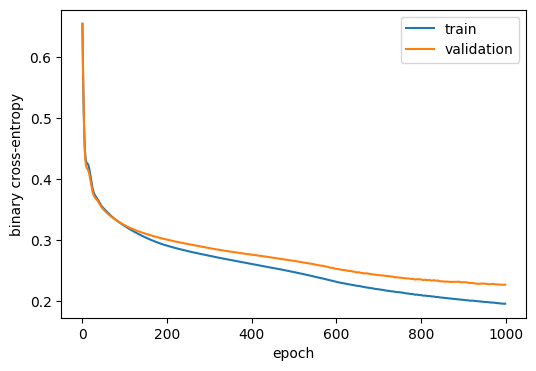

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="validation")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.legend()
plt.show()


## Estimated \(\beta\)'s

The displayed scaled estimates are the parameters used internally with \(\widetilde S\). The original-scale estimates divide by the relation-specific scale factor.


In [15]:
with torch.no_grad():
    beta_scaled = model.beta.detach().cpu()
    beta_original_scale = beta_scaled / S_scale.cpu()

beta_df = pd.DataFrame({
    "parameter": BETA_LABELS,
    "estimate_on_scaled_S": beta_scaled.numpy(),
    "estimate_original_S_scale": beta_original_scale.numpy(),
})

beta_df


,parameter,estimate_on_scaled_S,estimate_original_S_scale
0,beta_1: net_rur,0.612283,0.200952
1,beta_2: net_rsr,0.166930,0.003266
2,beta_3: net_rtr,0.062824,0.006736


## Learned neural field \(b_\theta(X_i)\)

The following computes the learned scalar external field at each node. This is the nonlinear analogue of \(X_i^\top\gamma\).


In [16]:
@torch.no_grad()
def compute_learned_field(model, X, device):
    model.eval()
    b = model.field(X.to(device).float())
    return b.detach().cpu()


b_hat = compute_learned_field(model, X, device)

field_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "all"],
    "mean_b_hat": [
        float(b_hat[train_mask].mean()),
        float(b_hat[val_mask].mean()),
        float(b_hat[test_mask].mean()),
        float(b_hat.mean()),
    ],
    "std_b_hat": [
        float(b_hat[train_mask].std(unbiased=False)),
        float(b_hat[val_mask].std(unbiased=False)),
        float(b_hat[test_mask].std(unbiased=False)),
        float(b_hat.std(unbiased=False)),
    ],
})

field_summary


,split,mean_b_hat,std_b_hat
0,train,-0.479371,0.529808
1,validation,-0.472745,0.515973
2,test,-0.477670,0.516405
3,all,-0.478368,0.525784


In [17]:
pd.DataFrame({
    "y": y01.numpy(),
    "sigma": sigma_all.numpy(),
    "b_hat": b_hat.numpy(),
    "train": train_mask.numpy(),
    "validation": val_mask.numpy(),
    "test": test_mask.numpy(),
}).groupby("y")["b_hat"].describe()


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
0,39277.0,-0.589020,0.458428,-3.28610,-0.837409,-0.543328,-0.284154,1.155083
1,6677.0,0.172535,0.413239,-1.76869,-0.099601,0.165259,0.437237,1.776448


## Prediction and evaluation

We report metrics at threshold \(0.5\), and also at a threshold chosen on the validation set to maximize balanced accuracy.


In [18]:
masks = {
    "train": train_mask,
    "validation": val_mask,
    "test": test_mask,
}

metrics_05 = evaluate_splits(
    model=model,
    S=S,
    X=X,
    y01=y01,
    masks=masks,
    threshold=0.5,
    device=device,
)

metrics_05


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.5,32167,0.146921,0.923431,0.772787,0.874050,0.559458,0.682235,27060,381,2082,2644,0.948486,0.821742,train
1,0.5,4595,0.141676,0.907943,0.730906,0.783582,0.483871,0.598291,3857,87,336,315,0.921391,0.724098,validation
2,0.5,9192,0.141427,0.912859,0.743967,0.803159,0.508462,0.622704,7730,162,639,661,0.920550,0.733722,test


In [19]:
prob = predict_prob(model, S, X, device).numpy()
y_np = y01.numpy().astype(int)

val_idx = val_mask.numpy().astype(bool)
best_t_balacc, best_val_balacc = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="balanced_accuracy",
)

best_t_f1, best_val_f1 = select_threshold(
    y_true=y_np[val_idx],
    score=prob[val_idx],
    objective="f1",
)

print("Best validation threshold for balanced accuracy:", best_t_balacc, "value:", best_val_balacc)
print("Best validation threshold for F1:", best_t_f1, "value:", best_val_f1)


Best validation threshold for balanced accuracy: 0.151 value: 0.8389721850920568
Best validation threshold for F1: 0.333 value: 0.6625


In [20]:
metrics_val_balacc = evaluate_splits(
    model=model,
    S=S,
    X=X,
    y01=y01,
    masks=masks,
    threshold=best_t_balacc,
    device=device,
)

metrics_val_balacc


,threshold,n,positive_rate,accuracy,balanced_accuracy,precision_pos,recall_pos,f1_pos,tn,fp,fn,tp,roc_auc,average_precision,split
0,0.151,32167,0.146921,0.862281,0.874179,0.518213,0.891028,0.655307,23526,3915,515,4211,0.948486,0.821742,train
1,0.151,4595,0.141676,0.840261,0.838972,0.464621,0.837174,0.597588,3316,628,106,545,0.921391,0.724098,validation
2,0.151,9192,0.141427,0.845409,0.837689,0.473360,0.826923,0.602072,6696,1196,225,1075,0.920550,0.733722,test


## Inspect the local field decomposition

For each node,

$$
h_i
=
\underbrace{\sum_{r=1}^3\beta_r\widetilde S_{ir}}_{\text{graph interaction field}}
+
\underbrace{2b_\theta(X_i)}_{\text{neural external field}}.
$$

The following cell stores these components.


In [21]:
@torch.no_grad()
def local_field_decomposition(model, S, X, device):
    model.eval()

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()

    beta = model.beta.detach()
    graph_field = S_dev @ beta
    neural_field = 2.0 * model.field(X_dev)
    total_h = graph_field + neural_field
    prob = torch.sigmoid(2.0 * total_h)

    return pd.DataFrame({
        "graph_field": graph_field.cpu().numpy(),
        "neural_external_field_2b": neural_field.cpu().numpy(),
        "total_h": total_h.cpu().numpy(),
        "prob_label_1": prob.cpu().numpy(),
        "label": y01.numpy(),
        "train": train_mask.numpy(),
        "validation": val_mask.numpy(),
        "test": test_mask.numpy(),
    })


field_decomp_df = local_field_decomposition(model, S, X, device)
field_decomp_df.head()


,graph_field,neural_external_field_2b,total_h,prob_label_1,label,train,validation,test
0,-0.003266,-1.028397,-1.031663,0.112713,0,False,True,False
1,0.000000,-0.494348,-0.494348,0.271170,0,True,False,False
2,0.000000,-1.065150,-1.065150,0.106186,0,True,False,False
3,0.003266,-0.260561,-0.257295,0.374118,0,False,False,True
4,0.003470,-0.670748,-0.667278,0.208407,0,False,False,True


In [22]:
field_decomp_df.groupby("label")[[
    "graph_field",
    "neural_external_field_2b",
    "total_h",
    "prob_label_1",
]].describe()


graph_field                                                              \
            count      mean       std       min       25%       50%       75%   
label                                                                           
0         39277.0 -0.679423  0.675008 -8.091524 -0.832681 -0.511900 -0.283303   
1          6677.0 -0.246189  0.233433 -1.414906 -0.396783 -0.237994 -0.093690   

                neural_external_field_2b            ...   total_h            \
            max                    count      mean  ...       75%       max   
label                                               ...                       
0      0.356376                  39277.0 -1.178041  ... -1.169179  1.686391   
1      1.139375                   6677.0  0.345070  ...  0.652792  3.482680   

      prob_label_1                                                        \
             count      mean       std           min       25%       50%   
label                                                                      
0          39277.0  0.074027  0.114891  2.298573e-12  0.008262  0.028622   
1           6677.0  0.532127  0.287185  8.569374e-04  0.282777  0.549045   

                           
            75%       max  
label                      
0      0.087996  0.966843  
1      0.786773  0.999057  

[2 rows x 32 columns]

## Optional: fully neural local-field model

The previous model preserves the Gibbs form with three interpretable \(\beta\)'s and a nonlinear external field. A more flexible alternative is

$$
h_i=f_\theta(X_i,\widetilde S_{i1},\widetilde S_{i2},\widetilde S_{i3}).
$$

This is best interpreted as a neural pseudo-likelihood classifier. It generally does not correspond to an Ising model with interpretable \(\beta_1,\beta_2,\beta_3\).


In [23]:
class FullyNeuralLocalFieldMPLE(nn.Module):
    def __init__(self, n_features, n_relations=3, hidden=64, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_features + n_relations, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def logits(self, S, X):
        Z = torch.cat([S, X], dim=1)
        h = self.net(Z).squeeze(-1)
        return 2.0 * h

    def forward(self, S, X):
        return self.logits(S, X)


In [24]:
def train_fully_neural_mple(
    S,
    X,
    y01,
    train_mask,
    val_mask,
    hidden=64,
    dropout=0.2,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=1000,
    patience=100,
    use_pos_weight=False,
    device=None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    S_dev = S.to(device).float()
    X_dev = X.to(device).float()
    y_dev = y01.to(device).float()
    train_mask_dev = train_mask.to(device).bool()
    val_mask_dev = val_mask.to(device).bool()

    model = FullyNeuralLocalFieldMPLE(
        n_features=X.shape[1],
        n_relations=S.shape[1],
        hidden=hidden,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    if use_pos_weight:
        y_train = y01[train_mask].float()
        pos_weight_value = (y_train.numel() - y_train.sum()).item() / max(float(y_train.sum().item()), 1.0)
        pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
    else:
        pos_weight_value = None
        pos_weight = None

    history = []
    best_state = None
    best_val_loss = float("inf")
    best_epoch = -1
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        logits = model(S_dev, X_dev)
        train_loss = F.binary_cross_entropy_with_logits(
            logits[train_mask_dev],
            y_dev[train_mask_dev],
            pos_weight=pos_weight,
        )

        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(S_dev, X_dev)

            val_loss = F.binary_cross_entropy_with_logits(
                logits_eval[val_mask_dev],
                y_dev[val_mask_dev],
            )

            train_loss_eval = F.binary_cross_entropy_with_logits(
                logits_eval[train_mask_dev],
                y_dev[train_mask_dev],
            )

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss_eval.item()),
            "val_loss": float(val_loss.item()),
        })

        if val_loss.item() < best_val_loss - 1e-6:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 50 == 0:
            print(
                f"epoch={epoch:4d} "
                f"train_loss={train_loss_eval.item():.5f} "
                f"val_loss={val_loss.item():.5f}"
            )

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)

    return model, history_df, {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "pos_weight": pos_weight_value,
    }


In [25]:
# Uncomment this block to fit the fully neural local-field model.

# fully_neural_model, fully_neural_history, fully_neural_info = train_fully_neural_mple(
#     S=S,
#     X=X,
#     y01=y01,
#     train_mask=train_mask,
#     val_mask=val_mask,
#     hidden=64,
#     dropout=0.2,
#     lr=1e-3,
#     weight_decay=1e-4,
#     max_epochs=1000,
#     patience=100,
#     use_pos_weight=False,
#     device=device,
# )
#
# fully_neural_info


In [26]:
# Uncomment this block after fitting the fully neural model.

# prob_full = predict_prob(fully_neural_model, S, X, device).numpy()
# val_idx = val_mask.numpy().astype(bool)
#
# best_t_full, best_val_balacc_full = select_threshold(
#     y_true=y_np[val_idx],
#     score=prob_full[val_idx],
#     objective="balanced_accuracy",
# )
#
# evaluate_splits(
#     model=fully_neural_model,
#     S=S,
#     X=X,
#     y01=y01,
#     masks=masks,
#     threshold=best_t_full,
#     device=device,
# )


## Save fitted outputs


In [27]:
# Edit ROWNAME before running if you want a custom label in the CSV.
from pathlib import Path

ROWNAME = "S_unweigh_neural"

# For Colab, set SAVE_TO_GOOGLE_DRIVE=True and edit GOOGLE_DRIVE_METRICS_CSV_PATH.
SAVE_TO_GOOGLE_DRIVE = True
GOOGLE_DRIVE_METRICS_CSV_PATH = "/content/drive/MyDrive/yelp_metrics.csv"

if SAVE_TO_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    METRICS_CSV_PATH = Path(GOOGLE_DRIVE_METRICS_CSV_PATH)
else:
    METRICS_CSV_PATH = Path("script/yelp/yelp_metrics.csv") if Path("script/yelp").exists() else Path("yelp_metrics.csv")

if "metrics_val_f1" not in globals():
    metrics_val_f1 = evaluate_splits(
        model=model,
        S=S,
        X=X,
        y01=y01,
        masks=masks,
        threshold=best_t_f1,
        device=device,
    )


OUTPUT_COLUMNS = [
    "rowname",
    "threhold_type",
    "threshold_value",
    "f_1",
    "balanced_accuracy",
    "roc-aoc",
    "precision_pos",
    "recall_pos",
]


def append_test_metric_rows(rowname, threshold_frames, csv_path=METRICS_CSV_PATH):
    csv_path = Path(csv_path)
    rows = []

    for threshold_type, frame in threshold_frames.items():
        test_rows = frame.loc[frame["split"].astype(str).str.lower().eq("test")]
        if test_rows.empty:
            raise ValueError(f"No test split found in {threshold_type}")

        test_row = test_rows.iloc[0]
        rows.append({
            "rowname": rowname,
            "threhold_type": threshold_type,
            "threshold_value": test_row["threshold"],
            "f_1": test_row["f1_pos"],
            "balanced_accuracy": test_row["balanced_accuracy"],
            "roc-aoc": test_row["roc_auc"],
            "precision_pos": test_row["precision_pos"],
            "recall_pos": test_row["recall_pos"],
        })

    saved = pd.DataFrame(rows, columns=OUTPUT_COLUMNS)
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    if csv_path.exists():
        existing = pd.read_csv(csv_path)
        if list(existing.columns) == OUTPUT_COLUMNS:
            saved = pd.concat([existing, saved], ignore_index=True)

    saved.to_csv(csv_path, index=False)
    print(f"Saved {len(rows)} test metric rows to {csv_path}")
    return saved.tail(len(rows))


threshold_frames = {
    "0.5": metrics_05,
    "best_balanced_accuracy": metrics_val_balacc,
    "best_f1": metrics_val_f1,
}

saved_metric_rows = append_test_metric_rows(ROWNAME, threshold_frames)
saved_metric_rows


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 3 test metric rows to /content/drive/MyDrive/yelp_metrics.csv


,rowname,threhold_type,threshold_value,f_1,balanced_accuracy,roc-aoc,precision_pos,recall_pos
15,S_unweigh_neural,0.5,0.500,0.622704,0.743967,0.92055,0.803159,0.508462
16,S_unweigh_neural,best_balanced_accuracy,0.151,0.602072,0.837689,0.92055,0.473360,0.826923
17,S_unweigh_neural,best_f1,0.333,0.666403,0.799712,0.92055,0.685366,0.648462


In [26]:
results = {
    "model_type": "neural_external_field_mple",
    "edge_types": EDGE_TYPES,
    "neighbor_normalization": NEIGHBOR_NORMALIZATION,
    "source_labels_for_neighbor_sums": (
        "train_mask_only"
        if torch.equal(SOURCE_LABEL_MASK_FOR_NEIGHBOR_SUMS, train_mask)
        else "custom"
    ),
    "fit_info": fit_info,
    "beta_scaled": beta_scaled.numpy().tolist(),
    "beta_original_scale": beta_original_scale.numpy().tolist(),
    "threshold_05_metrics": metrics_05.to_dict(orient="records"),
    "threshold_val_balanced_accuracy": best_t_balacc,
    "threshold_val_balanced_accuracy_metrics": metrics_val_balacc.to_dict(orient="records"),
}

pd.Series(results)


,0
model_type,neural_external_field_mple
edge_types,"[net_rur, net_rsr, net_rtr]"
neighbor_normalization,none
source_labels_for_neighbor_sums,train_mask_only
fit_info,"{'best_epoch': 991, 'best_val_loss': 0.2262808..."
beta_scaled,"[0.6107662916183472, 0.1669614613056183, 0.063..."
beta_original_scale,"[0.20045414566993713, 0.003266288200393319, 0...."
threshold_05_metrics,"[{'threshold': 0.5, 'n': 32167, 'positive_rate..."
threshold_val_balanced_accuracy,0.149
threshold_val_balanced_accuracy_metrics,"[{'threshold': 0.149, 'n': 32167, 'positive_ra..."
